🔍 Buscando datos para KIC 8462852...


<Figure size 1000x500 with 0 Axes>

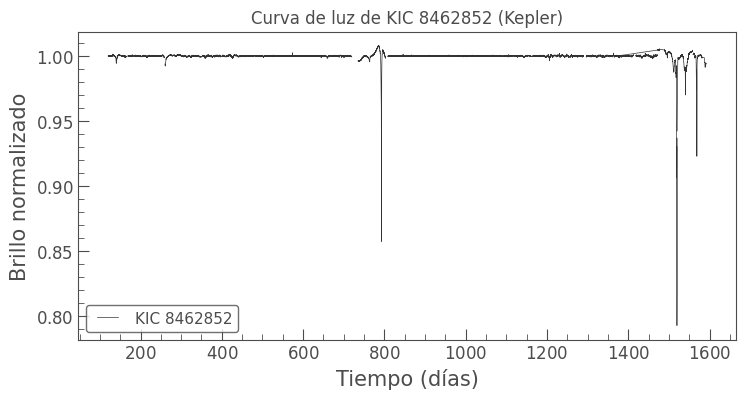

⚠️ Error al buscar datos para KIC 8462852: [Errno 28] No space left on device
🔍 Buscando datos para KIC 12557548...


<Figure size 1000x500 with 0 Axes>

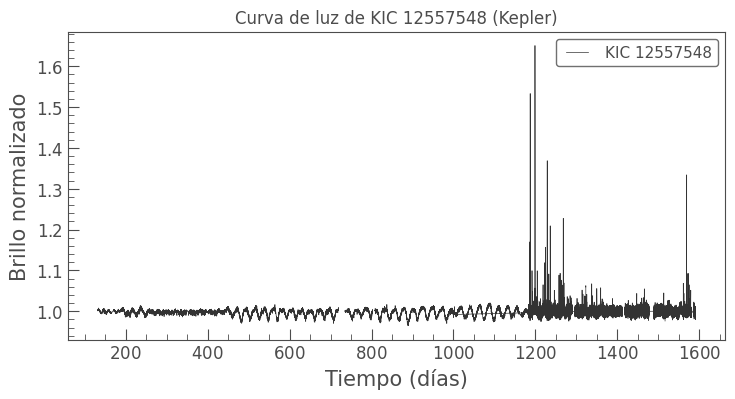

⚠️ Error al buscar datos para KIC 12557548: [Errno 28] No space left on device
🔍 Buscando datos para KIC 3544595...


<Figure size 1000x500 with 0 Axes>

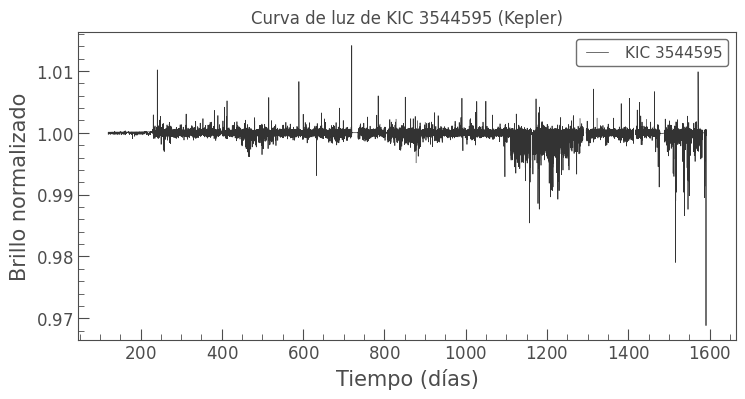

In [ ]:
import lightkurve as lk
import matplotlib.pyplot as plt
import os


# Lista de estrellas a descargar (se eliminó KIC 3347538 y se agregó Kepler-10)
target_stars = [
   # Anómalas y estudiadas
    "KIC 8462852", "KIC 12557548", "KIC 3544595", "KIC 8197761", "KIC 3733735",
    "KIC 6678383", "KIC 9930975", "KIC 10748390", "KIC 7446357", "KIC 4472809",
    "KIC 4276994", "KIC 8054146", "KIC 11442793", "KIC 11498538", "KIC 3861595",
    "KIC 2305930", "KIC 6933899", "KIC 10923629", "KIC 3247294", "KIC 10963065",
    "KIC 4282909", "KIC 3544594", "KIC 8219268", "KIC 8751933", "KIC 7767565",
    "KIC 7436415", "KIC 8552719", "KIC 12019440", "KIC 10982867", "KIC 4275989",
    "KIC 5524720", "KIC 9710326", "KIC 5351250", "KIC 4947556", "KIC 3231341",
    "KIC 6185331", "KIC 2570214", "KIC 9625170", "KIC 3532985", "KIC 9965715",
    "KIC 2853093", "KIC 10208303", "KIC 9655129", "KIC 8745553", "KIC 8846138",
    "KIC 8161661", "KIC 2306756", "KIC 7341231", "KIC 7219825", "KIC 11122894",

    # Estrellas con planetas confirmados (Kepler exoplanets)
    "Kepler-10", "Kepler-22", "Kepler-62", "Kepler-69", "Kepler-186", "Kepler-442",
    "Kepler-452", "Kepler-11", "Kepler-20", "Kepler-36", "Kepler-90", "Kepler-80",
    "Kepler-444", "Kepler-62f", "Kepler-186f", "Kepler-283c", "Kepler-62e",
    "Kepler-296e", "Kepler-438b", "Kepler-442b",

    # Estrellas normales (para comparar o calibrar)
    "KIC 10227020", "KIC 5096805", "KIC 2837475", "KIC 3241581", "KIC 2437488"
]

# Definir la carpeta donde guardar los datos
save_path = "/home/hammouchsara/PythonProject/data/raw"
os.makedirs(save_path, exist_ok=True)

os.makedirs(save_path, exist_ok=True)  # Crea la carpeta si no existe

for target_star in target_stars:
    print(f"🔍 Buscando datos para {target_star}...")

    try:
        lc_collection = lk.search_lightcurve(target_star, mission="Kepler").download_all()

        if lc_collection is not None:
            lc = lc_collection.stitch()  # Unir datos fragmentados si hay varios archivos

            # Graficar la curva de luz
            plt.figure(figsize=(10, 5))
            lc.plot()
            plt.title(f"Curva de luz de {target_star} (Kepler)")
            plt.xlabel("Tiempo (días)")
            plt.ylabel("Brillo normalizado")
            plt.show()

            # Convertir la curva de luz en un DataFrame
            lc_df = lc.to_pandas()

            # Nombre del archivo de salida
            file_name = os.path.join(save_path, f"curva_luz_{target_star.replace(' ', '_')}.csv")

            # Guardar el archivo CSV
            lc_df.to_csv(file_name, index=False)
            print(f"✅ Archivo guardado en: {file_name}")

        else:
            print(f"❌ No se encontraron datos para {target_star}.")

    except Exception as e:
        print(f"⚠️ Error al buscar datos para {target_star}: {e}")
